# <center>六 LangGraph 事件流的应用

## 1. 事件流应用概述


&emsp;&emsp;在实际应用中，流式输出尤其适用于需要快速反馈的业务场景，如聊天机器人，因为**大语言模型可能需要几秒钟才能生成对查询的完整响应，这远远慢于应用程序对最终用户的响应速度约为 200-300 毫秒的阈值**，如果是涉及多个大模型调用的复杂应用程序，这种延时会变得更加明显。让应用程序感觉响应更快的关键策略是显示中间进度；即，通过 `token` 流式传输大模型`Token`的输出，以此来显著提升用户体验。而在开发阶段，利用流式输出功能可以准确追踪到事件的具体执行阶段，并捕获相关数据，从而接入不同逻辑的数据处理和决策流程。是我们在应用开发中必须理解和掌握的技术点。

&emsp;&emsp;流式输出功能在`LangGraph` 框架中的实现方式比较简单，因为`LangGraph`底层是基于 `LangChain` 构建的，所有就直接把`LangChain`中的回调系统拿过来使用了。在`LangChain`中的流式输出是：以块的形式传输最终输出，即一旦监测到有可用的块，就直接生成它。**最常见和最关键的流数据是大模型本身生成的输出。 大模型通常需要时间才能生成完整的响应，通过实时流式传输输出，用户可以在生成时看到部分结果，这可以提供即时反馈并有助于减少用户的等待时间。如下所示：

In [15]:
from langchain_openai import ChatOpenAI

# DeepSeek API 配置
key = "your-deepseek-api-key"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [16]:
chunks = []
async for chunk in llm.astream("你好，请你详细的介绍一下你自己。"):
    chunks.append(chunk)
    print(chunk.content, end="|", flush=True)

|你好|呀|！|很高兴|认识|你|！|😊|

|让我|详细|地|介绍一下|自己|：

|##| |我是|谁|
|我是|**|Deep|Se|ek|**|，|由|**|深度|求|索|公司|**|开发的|AI|助手|。|我是一个|纯|文本|模型|，|专注于|理解和|生成|自然|语言|，|帮助|大家|解决|各种|问题|。

|##| |我的|核心|能力|
|-| **|文本|处理|**|：|我|擅长|阅读|、|理解|、|分析和|生成|各类|文本|内容|
|-| **|文件|支持|**|：|可以|处理|上传|的图像|、|txt|、|pdf|、|ppt|、|word|、|ex|cel|等|文件|，|从中|提取|文字|信息|进行分析|
|-| **|联网|搜索|**|：|支持|联网|功能|（|需要|你在|Web|/|App|端|手动|开启|），|获取|最新|信息|
|-| **|超|长|上下文|**|：|拥有|**|1|M|上下文|窗口|**|，|可以|一次性|处理|《|三|体|》|三部|曲|这样|体|量的|书籍|！

|##| |我的|特点|
|-| **|完全|免费|**|：|没错|，|我是|免费的|！|目前|没有任何|收费|计划|
|-| **|多|平台|支持|**|：|可以通过|官方|应用|商店|下载|App|使用|，|支持|语音|输入|
|-| **|知识|更新|**|：|知识|截止|日期|为|202|5|年|5|月|
|-| **|热情|细腻|**|：|我会|用|温暖|、|贴|心的|方式|和你|交流|

|##| |我不能|做什么|
|-| |不支持|多|模态|识别|（|比如|直接|识别|图片|内容|），|但|可以|读取|图片|中的|文字|
|-| |不能|生成|图片|、|视频|等|多媒体|内容|

|##| |我的|风格|
|我喜欢|用|热情|、|细腻|的方式|和你|沟通|，|力求|让|每次|对话|都|轻松|愉快|。|无论|你是|想|聊天|、|学习|、|工作|还是|创作|，|我都会|尽力|帮助你|！

|有什么|我可以|帮|你的|吗|？|尽管|问我|吧|！|🌟|||

In [17]:
chunks[4]

AIMessageChunk(content='很高兴', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019fe640-726a-7b23-b13e-769386dd667f', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])

&emsp;&emsp;每一个块，都是一个`AIMessageChunk`对象，用来代表`AIMessage`对象的一部分。消息块在设计上是可加的，比如：

In [18]:
chunks[0] + chunks[1] + chunks[2] + chunks[3] + chunks[4] + chunks[5]

AIMessageChunk(content='你好呀！很高兴认识', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019fe640-726a-7b23-b13e-769386dd667f', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])

&emsp;&emsp;而进一步的，除了流式传输大模型的输出之外，通过更复杂的工作流程或管道流式传输进度也很有用，比如 `AI Agent` 中的中间处理过程，这就涉及到工作流概念。

## 2 LangGraph使用流输出

&emsp;&emsp;`LangGraph`框架中的工作流中由各个步骤的节点和边组成。这里的流式传输涉及在各个节点请求更新时跟踪图状态的变化。这样可以更精细地监控工作流中当前处于活动状态的节点，并在工作流经过不同阶段时提供有关工作流状态的实时更新。其实现方式也是和`LangChain`一样通过`.stream`和`.astream`方法执行流式输出，只不过适配到了图结构中。调用`.stream`和`.astream`方法时可以指定几种不同的模式，即：

- "values" ：在图中的每个步骤之后流式传输**状态**的完整值。
- "updates" ：在图中的每个步骤之后将更新流式传输到状态。如果在同一步骤中进行多个更新（例如运行多个节点），则这些更新将单独流式传输。
- "debug" ：在整个图的执行过程中流式传输尽可能多的信息，主要用于调试程序。
- "messages"：记录每个`messages`中的增量`token`。
- "custom"：自定义流，通过`LangGraph 的 StreamWriter`方法

<div align=center><img src="../pic/lesson06/1.png" width=60%></div>

&emsp;&emsp;首先来看`Stream`方法，该方法返回一个迭代器，在生成输出块时同步生成它们。我们可以使用`for`循环来实时处理每个块。生成的块的类型取决于正在流式传输的组件。例如，当从大模型流式传输时，每个组件将是一个`AIMessageChunk`，但是，对于其他组件，块可能会有所不同。其`LangGraph`框架中实现的源码如下：

> LangGraph Graph stream：https://langchain-ai.github.io/langgraph/reference/graphs/#langgraph.graph.graph.CompiledGraph.stream

```python
def stream(
    self,
    input: Union[dict[str, Any], Any],  # 图中的输入，从状态中取值
    config: Optional[RunnableConfig] = None,
    *,
    stream_mode: Optional[Union[StreamMode, list[StreamMode]]] = None,
    output_keys: Optional[Union[str, Sequence[str]]] = None,  # 流媒体的键，默认为所有非上下文通道。
    interrupt_before: Optional[Union[All, Sequence[str]]] = None,  # 中断之前的节点，默认为图中的所有节点。
    interrupt_after: Optional[Union[All, Sequence[str]]] = None,   # 中断之后的节点，默认为图中的所有节点。
    debug: Optional[bool] = None,   #  执行过程中是否打印调试信息，默认为False。
    subgraphs: bool = False,  # 是否流式传输子图
) -> Iterator[Union[dict[str, Any], Any]]:
```

In [19]:
from sqlalchemy import create_engine, Column, Integer, String, Float, BigInteger, text
from sqlalchemy.orm import sessionmaker, declarative_base

# 创建基类
Base = declarative_base()

# 定义 Weather 模型（字段与 WeatherAPI 归一化后的 JSON 结构对应）
class Weather(Base):
    __tablename__ = 'weather'
    city_id = Column(BigInteger, primary_key=True)       # id
    city_name = Column(String(50))                     # name
    lon = Column(Float)                                  # coord.lon
    lat = Column(Float)                                  # coord.lat
    condition_id = Column(Integer)                       # weather[0].id
    main_weather = Column(String(50))                    # weather[0].main
    description = Column(String(100))                    # weather[0].description
    icon = Column(String(200))                           # weather[0].icon
    temperature = Column(Float)                          # main.temp
    feels_like = Column(Float)                           # main.feels_like
    temp_min = Column(Float)                             # main.temp_min
    temp_max = Column(Float)                             # main.temp_max
    pressure = Column(Float)                             # main.pressure
    humidity = Column(Integer)                           # main.humidity
    visibility = Column(Integer)                         # visibility
    wind_speed = Column(Float)                           # wind.speed
    wind_deg = Column(Integer)                           # wind.deg
    clouds = Column(Integer)                             # clouds.all
    observed_at = Column(BigInteger)                     # dt


# 数据库连接配置（macOS 本地 MySQL）
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_DATABASE = "langgraph"

# 先创建数据库（如果不存在）
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/?charset=utf8mb4"
)
with server_engine.connect() as conn:
    conn.execute(text(
        f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE} "
        "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
    ))
    conn.commit()

DATABASE_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/"
    f"{MYSQL_DATABASE}?charset=utf8mb4"
)
engine = create_engine(DATABASE_URI)

# 表结构变更时重建表（开发环境）
Weather.__table__.drop(engine, checkfirst=True)
Base.metadata.create_all(engine)

# 创建会话
Session = sessionmaker(bind=engine)

In [20]:
import requests
import json
import time
from langchain_core.tools import tool
from typing import Union, Optional
from pydantic import BaseModel, Field

WEATHERAPI_KEY = "02d81e92a8664fb7a8a81039260908"
WEATHERAPI_CURRENT_URL = "https://api.weatherapi.com/v1/current.json"
WEATHERAPI_MAX_RETRIES = 3


def _condition_to_main(code: int) -> str:
    """Map WeatherAPI condition code to OpenWeather-style main category."""
    if code == 1000:
        return "Clear"
    if code in (1003, 1006, 1009):
        return "Clouds"
    if code in (1030, 1135, 1147):
        return "Mist"
    if code in (1087, 1273, 1276, 1279, 1282):
        return "Thunderstorm"
    if code in (1066, 1114, 1117, 1210, 1213, 1216, 1219, 1222, 1225, 1237, 1255, 1258):
        return "Snow"
    if code >= 1063:
        return "Rain"
    return "Unknown"


def _fetch_weatherapi_current(city_name: str) -> dict:
    """Fetch current weather from WeatherAPI.com with retries for transient SSL/network errors."""
    last_error = None
    for attempt in range(WEATHERAPI_MAX_RETRIES):
        try:
            response = requests.get(
                WEATHERAPI_CURRENT_URL,
                params={"key": WEATHERAPI_KEY, "q": city_name, "lang": "zh"},
                timeout=30,
            )
            response.raise_for_status()
            return response.json()
        except requests.RequestException as exc:
            last_error = exc
            if attempt < WEATHERAPI_MAX_RETRIES - 1:
                time.sleep(1.5 * (attempt + 1))
    raise RuntimeError(
        f"无法连接 WeatherAPI（城市: {city_name}）。"
        "这通常是网络或 SSL 握手问题，请检查代理/VPN 后重试。"
        f" 原始错误: {last_error}"
    ) from last_error


def _normalize_weather_payload(payload: dict, query_name: str) -> dict:
    """Normalize WeatherAPI.com response to the legacy OpenWeather-style shape."""
    location = payload["location"]
    current = payload["current"]
    condition = current["condition"]
    lat = location["lat"]
    lon = location["lon"]
    temp = current["temp_c"]
    city_id = int(abs(round(lat * 100)) * 1_000_000 + abs(round(lon * 100)))
    vis_km = current.get("vis_km")
    visibility = int(vis_km * 1000) if vis_km is not None else None

    return {
        "coord": {"lon": lon, "lat": lat},
        "weather": [{
            "id": condition["code"],
            "main": _condition_to_main(condition["code"]),
            "description": condition["text"],
            "icon": condition.get("icon", ""),
        }],
        "main": {
            "temp": temp,
            "feels_like": current.get("feelslike_c", temp),
            "temp_min": temp,
            "temp_max": temp,
            "pressure": current.get("pressure_mb"),
            "humidity": current.get("humidity"),
        },
        "visibility": visibility,
        "wind": {
            "speed": round(current.get("wind_kph", 0) / 3.6, 2),
            "deg": current.get("wind_degree"),
        },
        "clouds": {"all": current.get("cloud", 0)},
        "dt": current.get("last_updated_epoch"),
        "timezone": None,
        "id": city_id,
        "name": location.get("name", query_name),
        "cod": 200,
    }


def _get_weather_data(city_name: str) -> dict:
    payload = _fetch_weatherapi_current(city_name)
    return _normalize_weather_payload(payload, city_name)


def _weather_row_to_payload(weather_data: Weather) -> dict:
    """Convert a Weather ORM row to the same JSON shape returned by get_weather."""
    return {
        "coord": {"lon": weather_data.lon, "lat": weather_data.lat},
        "weather": [{
            "id": weather_data.condition_id,
            "main": weather_data.main_weather,
            "description": weather_data.description,
            "icon": weather_data.icon,
        }],
        "main": {
            "temp": weather_data.temperature,
            "feels_like": weather_data.feels_like,
            "temp_min": weather_data.temp_min,
            "temp_max": weather_data.temp_max,
            "pressure": weather_data.pressure,
            "humidity": weather_data.humidity,
        },
        "visibility": weather_data.visibility,
        "wind": {
            "speed": weather_data.wind_speed,
            "deg": weather_data.wind_deg,
        },
        "clouds": {"all": weather_data.clouds},
        "dt": weather_data.observed_at,
        "timezone": None,
        "id": weather_data.city_id,
        "name": weather_data.city_name,
        "cod": 200,
    }


## 第一个工具

class WeatherLoc(BaseModel):
    location: str = Field(description="The location name of the city")


class WeatherInfo(BaseModel):
    """Extracted weather information for a specific city."""
    city_id: int = Field(..., description="City ID from the `id` field")
    city_name: str = Field(..., description="City name from the `name` field")
    lon: float = Field(..., description="Longitude from `coord.lon`")
    lat: float = Field(..., description="Latitude from `coord.lat`")
    condition_id: int = Field(..., description="Weather condition code from `weather[0].id`")
    main_weather: str = Field(..., description="Main weather condition from `weather[0].main`")
    description: str = Field(..., description="Weather description from `weather[0].description`")
    icon: str = Field(..., description="Weather icon URL from `weather[0].icon`")
    temperature: float = Field(..., description="Current temperature from `main.temp`")
    feels_like: float = Field(..., description="Feels-like temperature from `main.feels_like`")
    temp_min: float = Field(..., description="Minimum temperature from `main.temp_min`")
    temp_max: float = Field(..., description="Maximum temperature from `main.temp_max`")
    pressure: float = Field(..., description="Air pressure from `main.pressure`")
    humidity: int = Field(..., description="Humidity from `main.humidity`")
    visibility: int = Field(..., description="Visibility in meters from `visibility`")
    wind_speed: float = Field(..., description="Wind speed in m/s from `wind.speed`")
    wind_deg: int = Field(..., description="Wind direction in degrees from `wind.deg`")
    clouds: int = Field(..., description="Cloud coverage percentage from `clouds.all`")
    observed_at: int = Field(..., description="Observation timestamp from `dt`")


@tool(args_schema=WeatherLoc)
def get_weather(location):
    """
    Function to query current weather.
    :param loc: Required parameter, of type string, representing the specific city name for the weather query. \
    Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing, \
    the loc parameter should be input as 'Beijing'.
    :return: Current weather from WeatherAPI.com, normalized to a JSON string.
    """
    try:
        data = _get_weather_data(location)
        return json.dumps(data, ensure_ascii=False)
    except Exception as exc:
        return json.dumps(
            {"error": f"Weather API request failed for {location}: {exc}"},
            ensure_ascii=False,
        )


## 第二个工具

@tool(args_schema=WeatherInfo)
def insert_weather_to_db(
    city_id,
    city_name,
    lon,
    lat,
    condition_id,
    main_weather,
    description,
    icon,
    temperature,
    feels_like,
    temp_min,
    temp_max,
    pressure,
    humidity,
    visibility,
    wind_speed,
    wind_deg,
    clouds,
    observed_at,
):
    """Insert weather information into the database."""
    session = Session()
    try:
        weather = Weather(
            city_id=city_id,
            city_name=city_name,
            lon=lon,
            lat=lat,
            condition_id=condition_id,
            main_weather=main_weather,
            description=description,
            icon=icon,
            temperature=temperature,
            feels_like=feels_like,
            temp_min=temp_min,
            temp_max=temp_max,
            pressure=pressure,
            humidity=humidity,
            visibility=visibility,
            wind_speed=wind_speed,
            wind_deg=wind_deg,
            clouds=clouds,
            observed_at=observed_at,
        )
        session.merge(weather)
        session.commit()
        return {"messages": [f"天气数据已成功存储至Mysql数据库。"]}
    except Exception as e:
        session.rollback()
        return {"messages": [f"数据存储失败，错误原因：{e}"]}
    finally:
        session.close()


## 第三个工具

class QueryWeatherSchema(BaseModel):
    """Schema for querying weather information by city name."""
    city_name: str = Field(..., description="The name of the city to query weather information")


@tool(args_schema=QueryWeatherSchema)
def query_weather_from_db(city_name: str):
    """Query weather information from the database by city name."""
    session = Session()
    try:
        weather_data = session.query(Weather).filter(Weather.city_name == city_name).first()
        if weather_data:
            return _weather_row_to_payload(weather_data)
        else:
            return {"messages": [f"未找到城市 '{city_name}' 的天气信息。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因：{e}"]}
    finally:
        session.close()


## 第四个工具

class SearchQuery(BaseModel):
    query: str = Field(description="Questions for networking queries")


@tool(args_schema=SearchQuery)
def fetch_real_time_info(query):
    """Get real-time Internet information"""
    url = "https://google.serper.dev/search"
    payload = json.dumps({
        "q": query,
        "num": 1,
    })
    headers = {
        "X-API-KEY": "09b88d55900377e05b0aa283b7cefa97ca73a439",
        "Content-Type": "application/json",
    }

    response = requests.post(url, headers=headers, data=payload)
    data = json.loads(response.text)
    if "organic" in data:
        return json.dumps(data["organic"], ensure_ascii=False)
    else:
        return json.dumps({"error": "No organic results found"}, ensure_ascii=False)

In [22]:
get_weather.invoke({"location": "beijing"})

'{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1000, "main": "Clear", "description": "晴天", "icon": "//cdn.weatherapi.com/weather/64x64/day/113.png"}], "main": {"temp": 28.3, "feels_like": 28.5, "temp_min": 28.3, "temp_max": 28.3, "pressure": 1008.0, "humidity": 47}, "visibility": 10000, "wind": {"speed": 2.61, "deg": 151}, "clouds": {"all": 10}, "dt": 1786274100, "timezone": null, "id": 3993011639, "name": "Beijing", "cod": 200}'

In [23]:
tools = [fetch_real_time_info, get_weather, insert_weather_to_db, query_weather_from_db]

In [24]:
tools

[StructuredTool(name='fetch_real_time_info', description='Get real-time Internet information', args_schema=<class '__main__.SearchQuery'>, func=<function fetch_real_time_info at 0x121ed4f40>),
 StructuredTool(name='get_weather', description="Function to query current weather.\n:param loc: Required parameter, of type string, representing the specific city name for the weather query.     Note that for cities in China, the corresponding English city name should be used. For example, to query the weather for Beijing,     the loc parameter should be input as 'Beijing'.\n:return: Current weather from WeatherAPI.com, normalized to a JSON string.", args_schema=<class '__main__.WeatherLoc'>, func=<function get_weather at 0x121f67b00>),
 StructuredTool(name='insert_weather_to_db', description='Insert weather information into the database.', args_schema=<class '__main__.WeatherInfo'>, func=<function insert_weather_to_db at 0x121f677e0>),
 StructuredTool(name='query_weather_from_db', description='

In [43]:
llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)

In [44]:
from langgraph.prebuilt import ToolNode, create_react_agent

tool_node = ToolNode(tools, handle_tool_errors=True)
graph = create_react_agent(llm, tools=tool_node)

/var/folders/hm/p5x9q0gj1tq37tdyp_pjmqgh0000gn/T/ipykernel_30988/122440714.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = create_react_agent(llm, tools=tool_node)


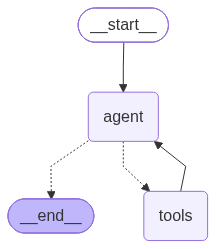

In [45]:
graph

<div align=center><img src="../pic/lesson06/1.png" width=60%></div>

- **values ：在图表的每个步骤之后流式传输状态的完整值。**

In [48]:
def print_stream_values(stream):
    """values 模式：每个 chunk 是完整 state，取 messages[-1] 即本步新增的消息。"""
    for sub_stream in stream:
        print(sub_stream)  # 取消注释可查看完整 state
        print("=================#############################====================================")
        # message = sub_stream["messages"][-1]
        # message.pretty_print()

input_message = {"messages": ["你好，北京现在的天气怎么样？"]}
print_stream_values(graph.stream(input_message, stream_mode="values"))

{'messages': [HumanMessage(content='你好，北京现在的天气怎么样？', additional_kwargs={}, response_metadata={}, id='75d7c3a6-2d49-430e-ad30-7e408b7184b5')]}
=================#############################====================================
{'messages': [HumanMessage(content='你好，北京现在的天气怎么样？', additional_kwargs={}, response_metadata={}, id='75d7c3a6-2d49-430e-ad30-7e408b7184b5'), AIMessage(content='我来帮你查询北京现在的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 1063, 'total_tokens': 1115, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 39}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '5bc0ea98-f07f-4e01-9dde-3fe517343049', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe65c-ecaa-7a60-bbcb-ab9e15a1de0b-0', 

- **updates ：在图中的每个步骤之后将更新流式传输到状态。**

In [49]:
def print_stream_updates(stream):
    """updates 模式：每个 chunk 是 {节点名: 本步增量}，需先取节点再读 messages。"""
    for chunk in stream:
        for node, values in chunk.items():
            print(f"接收到的更新节点: '{node}'")
            # print(chunk)  # 取消注释可查看原始 chunk
            values["messages"][-1].pretty_print()
            print()

input_message = {"messages": ["你好，北京现在的天气怎么样？"]}
print_stream_updates(graph.stream(input_message, stream_mode="updates"))

接收到的更新节点: 'agent'
================================== Ai Message ==================================

我来帮你查询北京现在的天气情况。
Tool Calls:
  get_weather (call_00_epK0VOQ47xpTAFIcDWUK6367)
 Call ID: call_00_epK0VOQ47xpTAFIcDWUK6367
  Args:
    location: Beijing

接收到的更新节点: 'tools'
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1000, "main": "Clear", "description": "晴天", "icon": "//cdn.weatherapi.com/weather/64x64/night/113.png"}], "main": {"temp": 28.3, "feels_like": 28.5, "temp_min": 28.3, "temp_max": 28.3, "pressure": 1008.0, "humidity": 47}, "visibility": 10000, "wind": {"speed": 2.61, "deg": 151}, "clouds": {"all": 10}, "dt": 1786275900, "timezone": null, "id": 3993011639, "name": "Beijing", "cod": 200}

接收到的更新节点: 'agent'
================================== Ai Message ==================================

我来为你查询北京现在的天气情况，同时将数据保存到数据库中。
Tool Calls:
  insert_weather_to_db (call_00_Wx1

- **debug ：在整个图中的执行过程中流式传输尽可能多的信息**

In [30]:
def print_stream(stream):
    for sub_stream in stream:
        print(sub_stream)  # 就是上面的示例中非流式直接调用的全部信息

input_message = {"messages": ["你好，北京现在的天气怎么样？"]}
print_stream(graph.stream(input_message, stream_mode="debug"))

{'step': 1, 'timestamp': '2026-08-09T11:24:21.768092+00:00', 'type': 'task', 'payload': {'id': 'dc583dfb-4314-7566-dee6-6736e284e144', 'name': 'agent', 'input': {'messages': [HumanMessage(content='你好，北京现在的天气怎么样？', additional_kwargs={}, response_metadata={}, id='b0788ea7-cb55-4989-8c43-3b7ce88352fb')], 'remaining_steps': 9999}, 'triggers': ('branch:to:agent',)}}
{'step': 1, 'timestamp': '2026-08-09T11:24:23.112246+00:00', 'type': 'task_result', 'payload': {'id': 'dc583dfb-4314-7566-dee6-6736e284e144', 'name': 'agent', 'error': None, 'result': {'messages': [AIMessage(content='我来帮你查询北京现在的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 1063, 'total_tokens': 1115, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 39}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 

&emsp;&emsp;如果在异步开发环境中，则可以使用`astream`方法来实现流式传输，是专为非阻塞工作流程而设计。可使用的模式和`stream`是一致的，只不过需要调整为异步函数的定义方法，代码如下所示：

In [31]:
async for chunk in graph.astream(input={"messages": ["你好，北京的天气怎么样？"]}, stream_mode="values"):
    message = chunk["messages"][-1].pretty_print()

================================ Human Message =================================

你好，北京的天气怎么样？
================================== Ai Message ==================================

我来帮你查询北京当前的天气情况。
Tool Calls:
  get_weather (call_00_SNPEDmNoSKeM2nhs9FB17455)
 Call ID: call_00_SNPEDmNoSKeM2nhs9FB17455
  Args:
    location: Beijing
================================= Tool Message =================================
Name: get_weather

{"coord": {"lon": 116.3883, "lat": 39.9289}, "weather": [{"id": 1000, "main": "Clear", "description": "晴天", "icon": "//cdn.weatherapi.com/weather/64x64/night/113.png"}], "main": {"temp": 28.3, "feels_like": 28.5, "temp_min": 28.3, "temp_max": 28.3, "pressure": 1008.0, "humidity": 47}, "visibility": 10000, "wind": {"speed": 2.61, "deg": 151}, "clouds": {"all": 10}, "dt": 1786274100, "timezone": null, "id": 3993011639, "name": "Beijing", "cod": 200}
================================== Ai Message ==================================

我来为你查询到北京当前的天气情况，让我把数据整理给你：

## ☀️ 北京当

&emsp;&emsp;如果只想得到最终结果，可以使用相同的方法并只跟踪收到的最后一个值，代码如下：

In [32]:
async for chunk in graph.astream(input={"messages": ["你好，北京的天气怎么样？"]}, stream_mode="values"):
    final_result = chunk

In [33]:
final_result["messages"][-1].pretty_print()

================================== Ai Message ==================================

北京当前的天气情况如下：

🌤️ **北京天气**

- **天气状况**：晴天（Clear）
- **当前温度**：28.3°C
- **体感温度**：28.5°C
- **最低/最高温度**：28.3°C / 28.3°C
- **湿度**：47%
- **气压**：1008 hPa
- **能见度**：10公里
- **风速**：2.61 m/s（东南风，风向151°）
- **云量**：10%

总体来说，北京目前是晴朗的好天气，温度舒适，湿度适中，非常适合外出活动。天气数据也已成功保存到数据库中。如果你还有其他城市想查询，随时告诉我！😊


In [34]:
inputs = {"messages": [("human", "你好，大理的天气怎么样？")]}
async for chunk in graph.astream(inputs, stream_mode="updates"):
    for node, values in chunk.items():
        print(f"接收到的更新节点: '{node}'")
        print(values)
        print("\n\n")

接收到的更新节点: 'agent'
{'messages': [AIMessage(content='我来帮你查询大理的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 1063, 'total_tokens': 1116, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 1024}, 'prompt_cache_hit_tokens': 1024, 'prompt_cache_miss_tokens': 39}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '172a861e-0ef9-4054-a046-9e1ba0caa257', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fe644-e678-72b1-8c67-db74aabf8521-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Dali'}, 'id': 'call_00_dgykuEpW8uTn9yB6N2AW4376', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1063, 'output_tokens': 53, 'total_tokens': 1116, 'input_token_details': {'cache_read': 1024}, 'output_token_details': {}})]}



接收到的更新节点: 'tools'
{'me

&emsp;&emsp;而如果我们想流式传输每个过程中的 `Tokens`， 代码如下：

In [52]:
from langchain_core.messages import AIMessageChunk, HumanMessage

# #inputs = [HumanMessage(content="what is the weather in sf")]

# first = True
# async for msg, metadata in graph.astream({"messages": ["你好，帮我查询一下数据库中Lijiang的天气数据"]}, stream_mode="messages"):
#     if msg.content and not isinstance(msg, HumanMessage):
#         print(msg.content, end="|", flush=True)

#     if isinstance(msg, AIMessageChunk):
#         if first:
#             gathered = msg
#             first = False
#         else:
#             gathered = gathered + msg

#         if msg.tool_call_chunks:
#             print(gathered.tool_calls)


# first = True
# gathered = None

# async for msg, metadata in graph.astream(
#     {"messages": ["你好，帮我查询一下数据库中Lijiang的天气数据"]},
#     stream_mode="messages",
# ):
#     if msg.content and not isinstance(msg, HumanMessage):
#         print(msg.content, end="", flush=True)

#     if isinstance(msg, AIMessageChunk):
#         gathered = msg if first else gathered + msg
#         first = False

# # 流结束后只打印一次
# if gathered and gathered.tool_calls:
#     print("\n\n最终 tool_calls:", gathered.tool_calls)


async for msg, metadata in graph.astream(
    {"messages": ["你好，帮我查询一下数据库中Lijiang的天气数据"]},
    stream_mode="messages",
):
    if msg.content and not isinstance(msg, HumanMessage):
        print(msg.content, end="", flush=True)
    if isinstance(msg, AIMessageChunk):
        gathered = gathered + msg
        if msg.tool_call_chunks:
            current = gathered.tool_calls
            if current != last_tool_calls:
                print(current)
                last_tool_calls = current

我来帮您查询数据库中Lijiang的天气数据。[{'name': 'query_weather_from_db', 'args': {'city_name': 'Lijiang'}, 'id': 'call_00_xGuAnleNIO9Q9Sb61yJV7958', 'type': 'tool_call'}, {'name': 'query_weather_from_db', 'args': {}, 'id': 'call_00_cN67cL93bIlXDFPUD6pw7908', 'type': 'tool_call'}]
{"coord": {"lon": 102.004, "lat": 23.5922}, "weather": [{"id": 1003, "main": "Clouds", "description": "局部多云", "icon": "//cdn.weatherapi.com/weather/64x64/day/116.png"}], "main": {"temp": 22.0, "feels_like": 24.6, "temp_min": 22.0, "temp_max": 22.0, "pressure": 1003.0, "humidity": 82}, "visibility": 10000, "wind": {"speed": 1.0, "deg": 217}, "clouds": {"all": 42}, "dt": 1786274100, "timezone": null, "id": 2359010200, "name": "Lijiang", "cod": 200}我已经成功从数据库中查询到了Lijiang的天气数据，以下是详细信息：

## 🌤️ Lijiang 天气数据

| 项目 | 数据 |
|------|------|
| **城市名称** | Lijiang |
| **天气状况** | 局部多云 (Clouds) |
| **天气描述** | 局部多云 |
| **当前温度** | 22.0°C |
| **体感温度** | 24.6°C |
| **最低温度** | 22.0°C |
| **最高温度** | 22.0°C |
| **气压** | 1003.0 hPa |
| **湿度** | 82% 

&emsp;&emsp;`astream`中其他的模式大家可以自行尝试，这里不重复进行说明，总体而言，我们要理解的是，同步`stream`和异步`astream`都是流式传输的默认实现，用于流式传输链中的最终输出。

## 3.2 LangGraph中的事件流

&emsp;&emsp;对于上述使用的`.stream()`或`.astream()`仅流式传输链中最后一步的输出，这对于一些对话聊天类的应用程序来说基本就足够了，但是当我们的`AI Agent`是一个使用了多个大模型调用的更复杂的链时，我们有时希望在最终输出中也使用到一些中间值。

&emsp;&emsp;如果想获取到这样的中间事件和步骤，可以使用`LangGraph`框架中的 `astream_events `方法，注意：此方法仅支持异步。用来访问自定义事件和中间输出。使用该方法运行图时，可以得到如下相关事件：

> LangChain CallBack：https://python.langchain.com/docs/concepts/callbacks/

<div align=center><img src="../pic/lesson06/2.png" width=60%></div>

&emsp;&emsp;如下代码可以打印包含流式聊天模型输出的事件，其中 version="v2" 参数是指定使用 测试版 API 的版本，现在必须指定。 


In [53]:
async for event in graph.astream_events({"messages": ["你好，请你介绍一下你自己"]}, version="v2"):
    kind = event["event"]
    print(f"{kind}: {event['name']}")

on_chain_start: LangGraph
on_chain_start: agent
on_chain_start: call_model
on_chain_start: RunnableSequence
on_chain_start: Prompt
on_chain_end: Prompt
on_chat_model_start: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: ChatOpenAI
on_chat_model_stream: Ch

&emsp;&emsp;这个过程明确标识了`Agent`执行的每个阶段。从`on_chain_start: LangGraph `开始，写入`__start__`节点，启动`call_model`节点（ on_chain_start: call_model ）。然后开始聊天模型调用（ on_chat_model_start: ChatOpenAI ), 按`token`的增量流式返回 ( on_chat_model_stream: ChatOpenAI ），直到聊天模型（ on_chat_model_end: ChatOpenAI ）输出完全部内容后停止。继而将结果写回通道（ ChannelWrite<call_model,messages> ），再次回到`call_model`节点做决策，最终完成整个图的运行流程。

&emsp;&emsp;我们可以从中提取具体的某个 `event`（事件），比如：

In [37]:
events = []
async for event in graph.astream_events({"messages": ["你好，请你介绍一下你自己"]}, version="v2"):
    events.append(event)

In [38]:
events[0]

{'event': 'on_chain_start',
 'data': {'input': {'messages': ['你好，请你介绍一下你自己']}},
 'name': 'LangGraph',
 'tags': [],
 'run_id': '019fe645-ec30-7d82-ac4f-9257a61b3670',
 'metadata': {},
 'parent_ids': []}

In [39]:
events[10]

{'event': 'on_chat_model_stream',
 'data': {'chunk': AIMessageChunk(content='我是', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019fe645-ec33-72d2-97d1-577cf7f0bc93', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])},
 'run_id': '019fe645-ec33-72d2-97d1-577cf7f0bc93',
 'name': 'ChatOpenAI',
 'tags': ['seq:step:2'],
 'metadata': {'langgraph_step': 1,
  'langgraph_node': 'agent',
  'langgraph_triggers': ('branch:to:agent',),
  'langgraph_path': ('__pregel_pull', 'agent'),
  'langgraph_checkpoint_ns': 'agent:d990aa54-2446-c72f-d879-0757074fd07a',
  'checkpoint_ns': 'agent:d990aa54-2446-c72f-d879-0757074fd07a',
  'model': 'deepseek-chat',
  'model_name': 'deepseek-chat',
  'stream': False,
  'temperature': 0.0,
  '_type': 'openai-chat',
  'ls_provider': 'openai',
  'ls_model_name': 'deepseek-chat',
  'ls_model_type': 'chat',
  'ls_temperature': 0.0,
  'ls_integration': 'langchain_chat_model'},
 'parent_ids': ['019fe645-ec30-7d82-ac4f-9257a61b36

&emsp;&emsp;所有事件都会包含`event` 、 `name`和`data`字段，其中：
- event ：正在发出的事件类型。
- name ：这是事件的名称
- data ：这是与事件关联的数据。

&emsp;&emsp;基于此就可以按照`name`、`tags`或`type`等不同的字段来进行事件过滤，比如我们现在选择仅包含聊天模型的输出：

In [40]:
async for event in graph.astream_events({"messages": ["你好，请你介绍一下你自己"]}, version="v2"):
    kind = event["event"]
    if kind == "on_chat_model_stream":
        print(event, end="|", flush=True)

{'event': 'on_chat_model_stream', 'data': {'chunk': AIMessageChunk(content='', additional_kwargs={}, response_metadata={'model_provider': 'openai'}, id='lc_run--019fe646-0a6f-7a11-ae2b-5525127a2a2b', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}, 'run_id': '019fe646-0a6f-7a11-ae2b-5525127a2a2b', 'name': 'ChatOpenAI', 'tags': ['seq:step:2'], 'metadata': {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:086bf0b1-b937-91d6-5898-c5ea28ccd756', 'checkpoint_ns': 'agent:086bf0b1-b937-91d6-5898-c5ea28ccd756', 'model': 'deepseek-chat', 'model_name': 'deepseek-chat', 'stream': False, 'temperature': 0.0, '_type': 'openai-chat', 'ls_provider': 'openai', 'ls_model_name': 'deepseek-chat', 'ls_model_type': 'chat', 'ls_temperature': 0.0, 'ls_integration': 'langchain_chat_model'}, 'parent_ids': ['019fe646-0a69-7bd3-a9cd-f4c91179f5c9', '019fe646-0a6c-78b3-a38e-c43ae1a0

&emsp;&emsp;每种类型的事件都包含不同格式的数据。而其中`data`是一个非常重要的，包含此事件的实际数据。在`on_chat_model_stream`事件中，就是需要响应的流式`Token`，如上图所示是一个 `AIMessageChunk`，其中包含消息的`content`以及`id` ,提取的代码就非常简单了，和我们上面实现的方式一致，即直接采用如下代码：

In [41]:
first = True
async for msg, metadata in graph.astream({"messages": ["你好，请你介绍一下你自己"]}, stream_mode="messages"):
    if msg.content and not isinstance(msg, HumanMessage):
        print(msg.content, end="|", flush=True)

    if isinstance(msg, AIMessageChunk):
        if first:
            gathered = msg
            first = False
        else:
            gathered = gathered + msg

        if msg.tool_call_chunks:
            print(gathered.tool_calls)

你好|！|我是|你的|AI|助手|，|很高兴|为你|服务|。

|我可以|帮你|完成|很多事情|，|比如|：

|1|.| **|查询|实时|信息|**| -| |我可以|联网|获取|最新的|互联网|信息|，|回答|你的|各种|问题|。

|2|.| **|查询|天气|**| -| |我可以|查询|全球|各大|城市的|当前|天气|情况|，|包括|温度|、|湿度|、|风速|、|天气|状况|等|详细信息|。

|3|.| **|管理|天气|数据|**| -| |我|还可以|将|查询|到的|天气|信息|存入|数据库|，|或者|从|数据库中|查询|历史|保存|的|天气|数据|。

|4|.| **|解答|问题|**| -| |无论是|生活|常识|、|专业知识|还是|其他|方面|的问题|，|我都会|尽力|为你|解答|。

|如果你|有任何|需要|，|随时|告诉我|！|比如|你想|了解|某个|城市的|天气|，|或者|想|查询|某些|实时|信息|，|我|都可以|帮你|处理|。|请问|有什么|我可以|帮|你的|吗|？|😊|

&emsp;&emsp;stream_mode="messages"模式是直接做的格式化提取的实现过程，当然，理解了上述事件流，我们也可以直接在当前的流程下自定义数据流，比如：

In [54]:
async for event in graph.astream_events({"messages": ["你好，请你介绍一下你自己"]}, version="v2"):
    kind = event["event"]
    if kind == "on_chat_model_stream":
        print(event["data"]["chunk"].content, end="", flush=True)

你好！我是你的AI助手，很高兴为你服务。

我可以帮你完成很多事情，比如：

1. **查询实时天气** — 我可以查询全球各大城市的当前天气情况，包括温度、湿度、风速、天气状况等信息。

2. **获取实时网络信息** — 我可以联网搜索最新的资讯、新闻、数据等信息。

3. **数据库操作** — 我可以将天气信息存入数据库，也可以从数据库中查询已保存的天气记录。

如果你有任何问题，比如想知道某个城市的天气、查找某些信息，或者需要我帮你处理数据，都可以随时告诉我！😊

请问有什么我可以帮你的吗？

&emsp;&emsp;由此可见，在处理事件流中的信息时，我们可以根据实际需求灵活地选择输出和展示的内容格式。这种灵活性正是在复杂业务流程中引入事件流的核心原因。

&emsp;&emsp;至此，我们就完整实现了在`LangGraph`中`ReAct`自治代理的完整构建，对于这个预构建的`ReAct`组件，它是集成了外部工具、记忆和规划三个核心概念，所以除了我们可以自定义外部工具以外，还可以给它制定不同的步骤规划方式，即`Planning`，以及通过`Memory`去赋予`Agent`多轮对话的能力，而这两部分的内容，我们将在下一节课程中展开详细的探讨和实践。